# Iris Flower Classification

**Objective:** Train a machine learning classification model to identify the species of an iris flower (*Setosa*, *Versicolor*, or *Virginica*) from its physical measurements (sepal length/width, petal length/width).

**Author:** Vivek Raj Jha
**Track:** Data Science — Oasis Infobyte Summer Internship Program (OIBSIP)
**Task:** Task 1 — Iris Flower Classification


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the Dataset
The Iris dataset is built directly into scikit-learn, so no external download is required.

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map(dict(enumerate(iris.target_names)))
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. Exploratory Data Analysis (EDA)

In [3]:
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())


Shape of dataset: (150, 6)

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name             str
dtype: object

Missing values per column:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


In [4]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
df['species_name'].value_counts()


species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 4. Visualisations

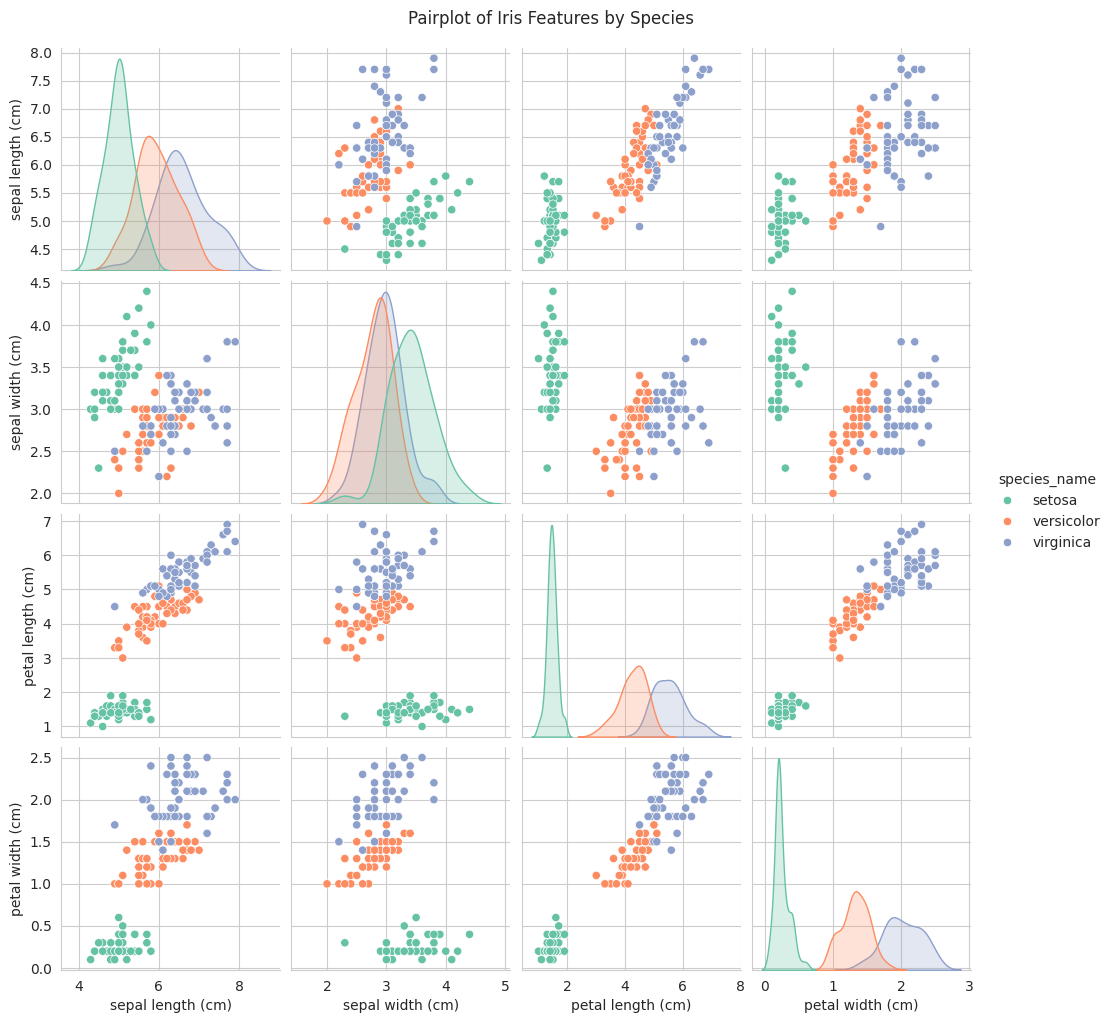

In [6]:
sns.pairplot(df, hue='species_name', vars=iris.feature_names, palette='Set2')
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.savefig('pairplot.png', bbox_inches='tight', dpi=120)
plt.show()


/tmp/ipykernel_479/2762635109.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=feature, ax=ax, palette='Set2')
/tmp/ipykernel_479/2762635109.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=feature, ax=ax, palette='Set2')


/tmp/ipykernel_479/2762635109.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=feature, ax=ax, palette='Set2')
/tmp/ipykernel_479/2762635109.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=feature, ax=ax, palette='Set2')


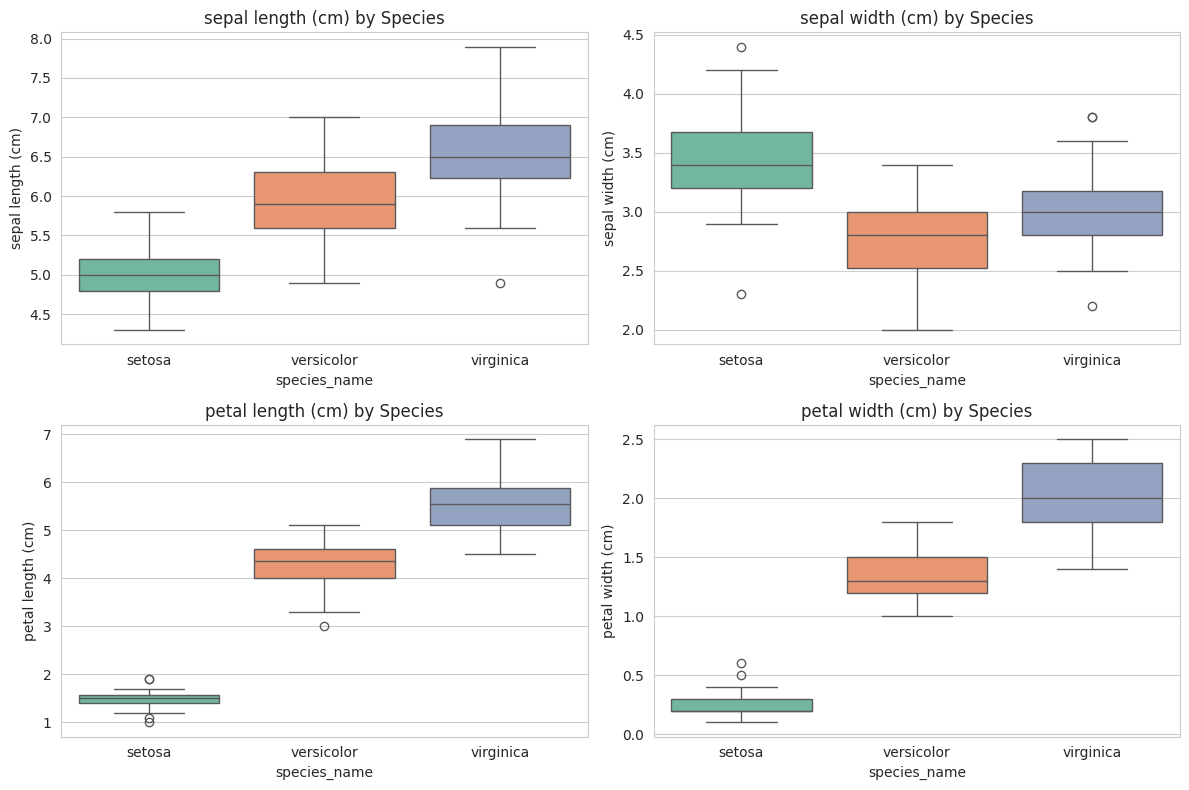

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), iris.feature_names):
    sns.boxplot(data=df, x='species_name', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'{feature} by Species')
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight', dpi=120)
plt.show()


## 5. Feature Selection Discussion

From the pairplot and boxplots above, **petal length** and **petal width** show the clearest separation between the three species — Setosa is almost perfectly separable using petal measurements alone, while Versicolor and Virginica have some overlap but are still fairly distinguishable. Sepal length and sepal width are less discriminative, showing more overlap between Versicolor and Virginica.

For this task, all four features are retained during training since the dataset is small and low-dimensional, but petal length/width are the most influential features for classification.


## 6. Train/Test Split

In [8]:
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 120
Testing samples: 30


## 7. Train Classification Models
Two classifiers are trained and compared: **Logistic Regression** and **K-Nearest Neighbours**. A **Decision Tree** is trained as a third comparison model.

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"model": model, "y_pred": y_pred, "accuracy": acc}
    print(f"{name}: Accuracy = {acc:.4f}")


Logistic Regression: Accuracy = 0.9667
K-Nearest Neighbours: Accuracy = 1.0000
Decision Tree: Accuracy = 0.9333


## 8. Model Evaluation

In [10]:
for name, res in results.items():
    print(f"\n===== {name} =====")
    print("Accuracy:", round(res['accuracy'], 4))
    print("\nClassification Report:\n", classification_report(y_test, res['y_pred'], target_names=iris.target_names))



===== Logistic Regression =====
Accuracy: 0.9667

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


===== K-Nearest Neighbours =====
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


===== Decision Tree =====
Accuracy: 0.9333

Classification Report:
               precisi

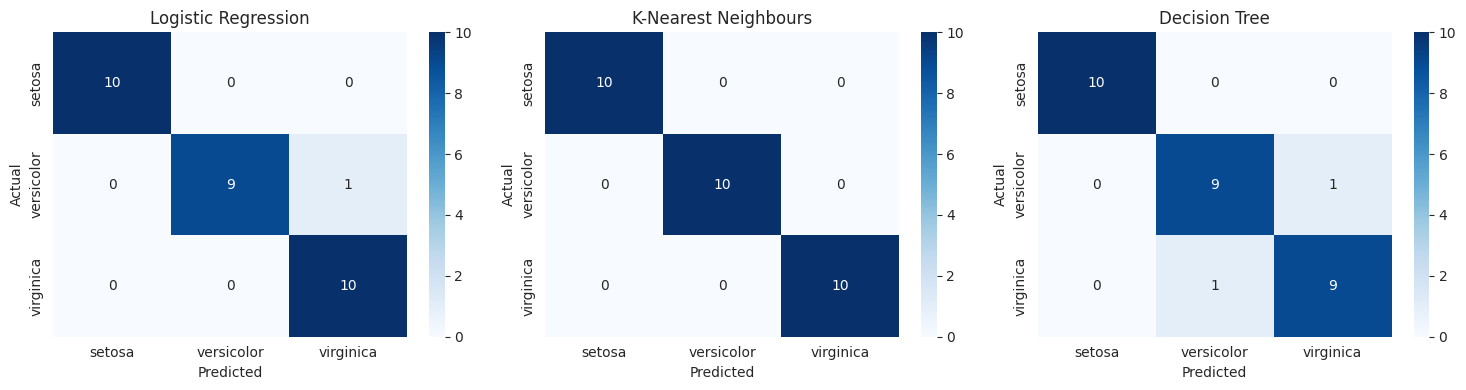

In [11]:
fig, axes = plt.subplots(1, len(models), figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()


## 9. Best-Performing Model

In [12]:
best_model_name = max(results, key=lambda name: results[name]['accuracy'])
print(f"Best-performing model: {best_model_name} with accuracy {results[best_model_name]['accuracy']:.4f}")


Best-performing model: K-Nearest Neighbours with accuracy 1.0000


**Justification:** All three models perform very well on the Iris dataset since the classes are largely linearly separable, especially using petal measurements. The best-performing model above is selected purely based on test accuracy. In practice, Logistic Regression and KNN are both strong and simple choices for this dataset, while the Decision Tree is more prone to overfitting on such a small dataset if not depth-limited.

## 10. Conclusion

- The Iris dataset is a classic, well-separated multi-class classification problem.
- Petal length and petal width are the most discriminative features.
- All trained models achieved high accuracy (typically 93–100%) on the test set.
- This notebook fulfils the OIBSIP Data Science Task 1 requirements: EDA, visualisations, feature discussion, train/test split, multiple classifiers, evaluation metrics, and best-model justification.
